In [1]:
1

1

In [2]:
import numpy


In [12]:
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.preprocessing import StandardScaler

# Load Fashion-MNIST dataset
(x_train, y_train), (_, _) = fashion_mnist.load_data()

# Use only 2000 samples for faster computation
num_samples = 2000
x_subset = x_train[:num_samples]
y_subset = y_train[:num_samples]

# Flatten the 28x28 images to 784-dimensional vectors
x_flat = x_subset.reshape(num_samples, -1)

# Standardize the pixel values using StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_flat)

print(f"Shape after flattening: {x_flat.shape}")
print(f"Shape after standardization: {x_scaled.shape}")


Shape after flattening: (2000, 784)
Shape after standardization: (2000, 784)


In [16]:
# !pip install tensorflow
# !pip install scikit-learn
# !pip install matplotlib


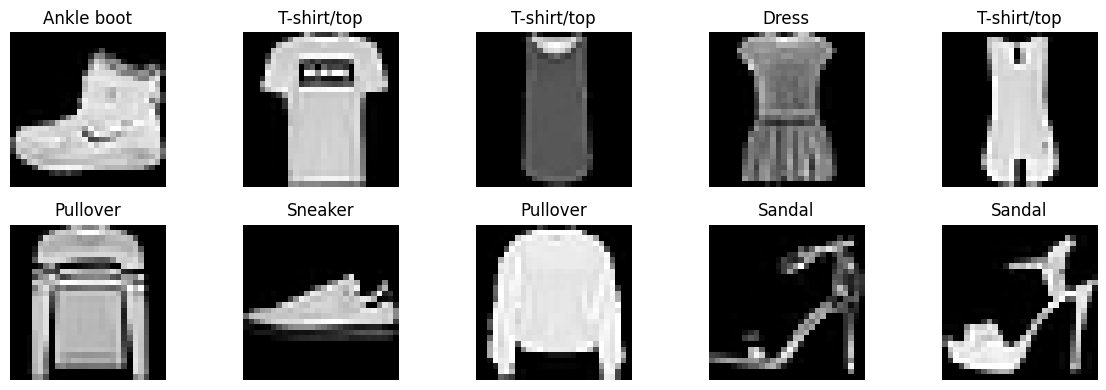

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist


class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [17]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print(f"Reduced shape: {x_pca.shape}")


Reduced shape: (2000, 2)


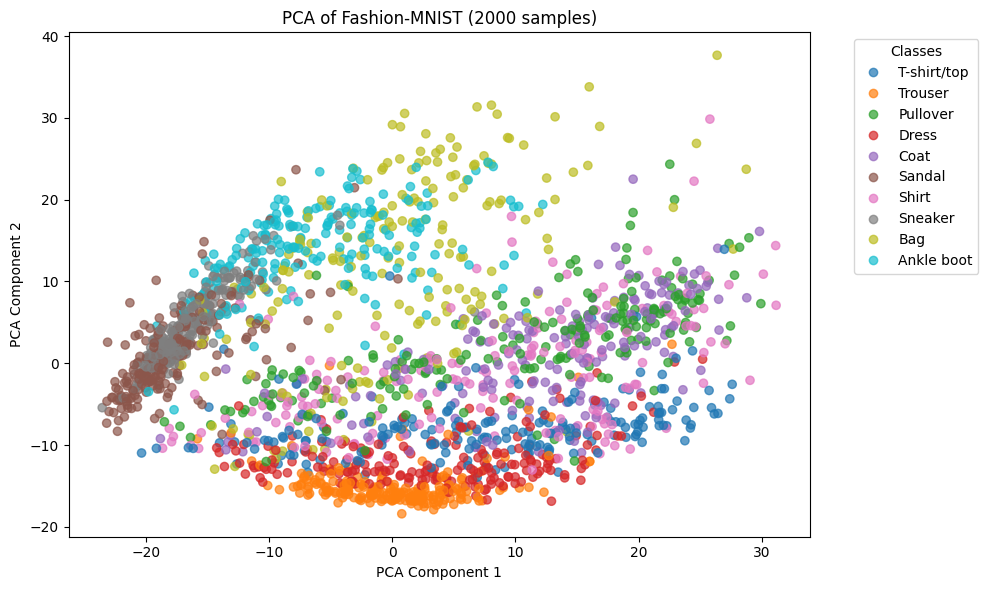

In [18]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y_subset, cmap='tab10', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA of Fashion-MNIST (2000 samples)')

# Add legend for classes
legend_labels = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
handles = scatter.legend_elements()[0]
plt.legend(handles, legend_labels, title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_scaled)

print(f"t-SNE reduced shape: {x_tsne.shape}")


t-SNE reduced shape: (2000, 2)


In [21]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_scaled)

print(f"Shape after t-SNE reduction: {x_tsne.shape}")


Shape after t-SNE reduction: (2000, 2)


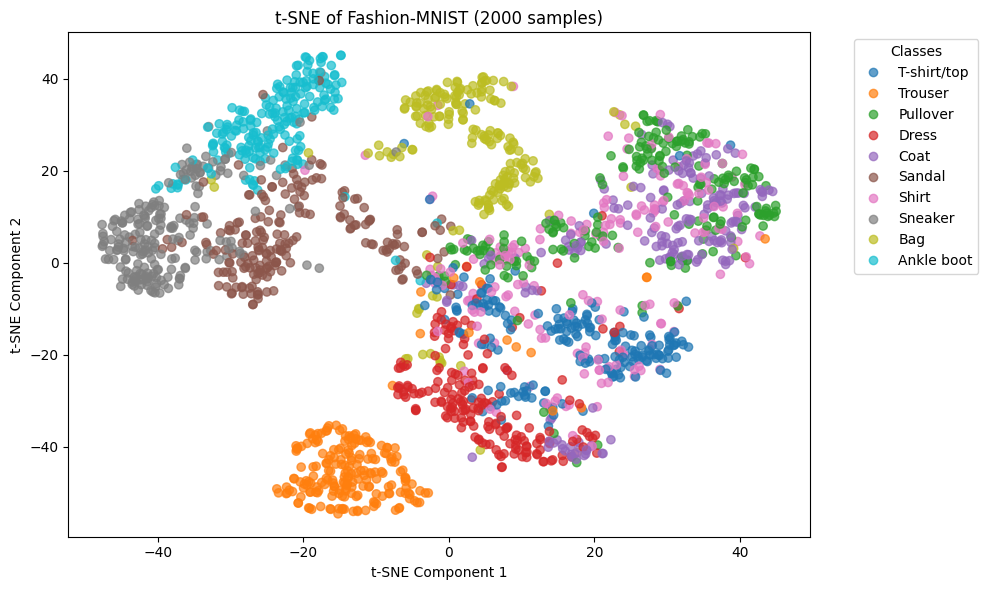

In [22]:

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]


plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_tsne[:, 0], x_tsne[:, 1], c=y_subset, cmap='tab10', alpha=0.7)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of Fashion-MNIST (2000 samples)')


handles = scatter.legend_elements()[0]
plt.legend(handles, class_names, title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import time
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# فرض بر این است که x_scaled آماده است (با StandardScaler)

# 1. زمان اجرای PCA
start_time = time.time()
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
pca_time = time.time() - start_time

# 2. زمان اجرای t-SNE
start_time = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_scaled)
tsne_time = time.time() - start_time

# چاپ زمان‌های اجرا
print(f"Time taken for PCA: {pca_time:.4f} seconds")
print(f"Time taken for t-SNE: {tsne_time:.4f} seconds")
